In [1]:
import argparse
import torch
%matplotlib inline

from isac.system import System
from isac.utils import set_random_seed

In [2]:
if __name__ == "__main__":

    batch_size = 128
    config_file = "test.toml"
    device = torch.device("cuda")
    seed = 42

    args = argparse.Namespace(batch_size=batch_size, config_file=config_file, device=device, seed=seed)

    # 设置随机种子
    set_random_seed(seed)

    system = System(args, config_file=config_file, device=device)

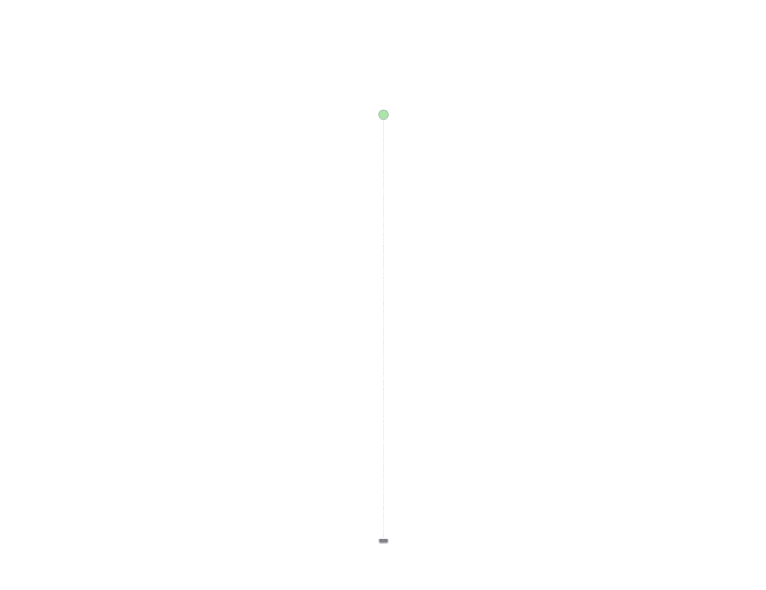

In [3]:
system.components.rt_scene.render()

In [ ]:
import numpy as np

from isac import PROJECT_ROOT

script_out_dir = PROJECT_ROOT / "out" / "sensing_baseline"
script_out_dir.mkdir(parents=True, exist_ok=True)

domain = "time"
system.components.rt_scene.get("reflector").velocity = [0, 0, -20]
system.components.rt_scene.get("bs1_tx").velocity = [30, 0, 0]

b = system.components.binary_source(
    [
        1,
        1,
        1,
        system.components.rg.num_data_symbols * system.params.qam.num_bits_per_symbol,
    ]
)
x = system.components.mapper(b)
x_rg = system.components.rg_mapper(x)

if domain == "frequency":
    y_rg = system.components.channel(x_rg, domain=domain)
elif domain == "time":
    x_time = system.components.modulator(x_rg)
    y_time = system.components.channel(x_time, domain=domain)
    y_rg = system.components.demodulator(y_time)
else:
    raise ValueError(f"不支持的域: {domain}")

y_rg = y_rg.squeeze()

h = system.components.channel.cfr(
    num_time_steps=system.components.rg.num_ofdm_symbols,
    sampling_frequency=1 / system.components.rg.ofdm_symbol_duration,
    out_type="numpy",
)
h = np.squeeze(h)

h_delay_doppler = system.components.delay_doppler_spectrum(h)

system.components.delay_doppler_spectrum.visualize(
    offset=20,
    file_name=script_out_dir / "sensing_baseline_delay_doppler_spectrum.png",
    to_db=False,
    mode="delay_doppler",
    backend="matplotlib",
)

system.components.music_estimator(
    spectrum_tensor=h_delay_doppler,
    mode="dd",
    sensing_performance=system.components.sensing_performance,
)

2026-03-27 14:47:41 - INFO - 使用MUSIC算法检测到 1 个谱峰:
2026-03-27 14:47:41 - INFO - 
┌────────┬────────────┬──────────────┬─────────────┬───────────────┬──────────────┐
│   峰值 │   时延索引 │   多普勒索引 │   时延 (ns) │   多普勒 (Hz) │   功率 (dBm) │
├────────┼────────────┼──────────────┼─────────────┼───────────────┼──────────────┤
│      1 │         10 │          496 │      325.52 │       -468.75 │       -16.77 │
└────────┴────────────┴──────────────┴─────────────┴───────────────┴──────────────┘
2026-03-27 14:47:41 - INFO - 目标径向距离估计: 48.794 m, 真值: 50.000 m, RMSE: 1.206 m
2026-03-27 14:47:41 - INFO - 目标径向速度估计: -27.025 m/s, 真值: 20.000 m/s, RMSE: 47.025 m/s
